<a href="https://colab.research.google.com/github/aruntakhur/GEU_ML_AUG_2026/blob/main/Lecture_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

torch.manual_seed(42)

In [54]:
transform = transforms.ToTensor()

train_dataset = MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

In [55]:
def filter_dataset(dataset):

    images = []
    labels = []

    for image, label in dataset:

        if label == 0:
            images.append(image.view(-1))
            labels.append(0)

        elif label == 4:
            images.append(image.view(-1))
            labels.append(1)

    images = torch.stack(images)
    labels = torch.tensor(labels)

    return images, labels


X_train, y_train = filter_dataset(train_dataset)
X_test, y_test = filter_dataset(test_dataset)

print("Training images :", X_train.shape)
print("Testing images  :", X_test.shape)

Training images : torch.Size([11765, 784])
Testing images  : torch.Size([1962, 784])


In [56]:
train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=64,
    shuffle=True
)

In [57]:
class LinearClassifier(nn.Module):

    def __init__(self):
        super().__init__()

        self.W = nn.Parameter(torch.randn(2,784)*0.01)
        self.b = nn.Parameter(torch.zeros(2))

    def forward(self, x):

        logits = x @ self.W.t() + self.b

        probabilities = torch.softmax(logits, dim=1)

        return probabilities

In [58]:
model = LinearClassifier()

print(model.W.shape)

torch.Size([2, 784])


In [59]:
def accuracy(model, X, y):

    with torch.no_grad():

        probs = model(X)

        prediction = torch.argmax(probs, dim=1)

        acc = (prediction == y).float().mean()

    return acc.item()*100

In [60]:
before_accuracy = accuracy(model, X_test, y_test)

print("Accuracy Before Training = {:.2f}%".format(before_accuracy))

Accuracy Before Training = 47.15%


torch.Size([784])
Add the extra dimension to make a desirable input of the model torch.Size([1, 784])
Softmax Probabilities
Digit 0 : 0.9999986886978149
Digit 4 : 1.321525928688061e-06

Predicted Digit : 0
Actual Digit    : 0


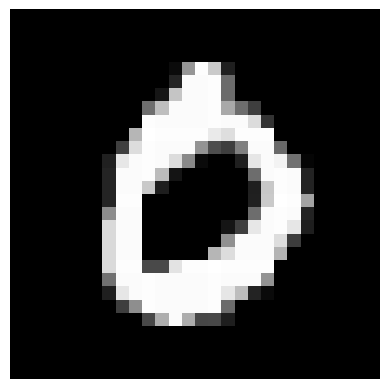

In [70]:
sample = X_test[0]
print(sample.shape)
print("Add the extra dimension to make a desirable input of the model: ",sample.unsqueeze(0).shape)
true_label = y_test[0]

with torch.no_grad():

    probability = model(sample.unsqueeze(0))

prediction = torch.argmax(probability, dim=1).item()

print("Softmax Probabilities")

print("Digit 0 :", probability[0,0].item())
print("Digit 4 :", probability[0,1].item())

print()

print("Predicted Digit :", 0 if prediction==0 else 4)
print("Actual Digit    :", 0 if true_label==0 else 4)

plt.imshow(sample.reshape(28,28), cmap="gray")
plt.axis("off")
plt.show()

In [62]:
criterion = nn.NLLLoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=0.1
)

In [63]:
loss_history = []
accuracy_history = []
weight_norm_history = []
update_norm_history = []
gradient_norm_history = []
confidence_history = []

previous_W = model.W.detach().clone()

epochs = 20

for epoch in range(epochs):

    running_loss = 0
    running_gradient = 0

    for images, labels in train_loader:

        optimizer.zero_grad()

        probs = model(images)

        log_probs = torch.log(probs + 1e-10)

        loss = criterion(log_probs, labels)

        loss.backward()

        running_gradient += model.W.grad.norm().item()

        optimizer.step()

        running_loss += loss.item()

    # Metrics after each epoch
    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = accuracy(model, X_test, y_test)
    weight_norm = model.W.norm().item()
    update_norm = torch.norm(model.W - previous_W).item()
    gradient_norm = running_gradient / len(train_loader)

    with torch.no_grad():
        sample_prob = model(sample.unsqueeze(0))
        confidence = sample_prob.max().item()

    previous_W = model.W.detach().clone()

    loss_history.append(epoch_loss)
    accuracy_history.append(epoch_accuracy)
    weight_norm_history.append(weight_norm)
    update_norm_history.append(update_norm)
    gradient_norm_history.append(gradient_norm)
    confidence_history.append(confidence)

    print(
        f"Epoch {epoch+1:2d} | "
        f"Loss={epoch_loss:.4f} | "
        f"Acc={epoch_accuracy:.2f}% | "
        f"WNorm={weight_norm:.4f} | "
        f"Update={update_norm:.4f} | "
        f"Grad={gradient_norm:.4f}"
    )

Epoch  1 | Loss=0.0475 | Acc=99.85% | WNorm=1.5923 | Update=1.5454 | Grad=0.1905
Epoch  2 | Loss=0.0202 | Acc=99.85% | WNorm=1.8416 | Update=0.2916 | Grad=0.0899
Epoch  3 | Loss=0.0172 | Acc=99.80% | WNorm=1.9948 | Update=0.1930 | Grad=0.0829
Epoch  4 | Loss=0.0155 | Acc=99.85% | WNorm=2.1126 | Update=0.1525 | Grad=0.0764
Epoch  5 | Loss=0.0143 | Acc=99.80% | WNorm=2.2083 | Update=0.1431 | Grad=0.0735
Epoch  6 | Loss=0.0137 | Acc=99.80% | WNorm=2.2900 | Update=0.1157 | Grad=0.0697
Epoch  7 | Loss=0.0131 | Acc=99.80% | WNorm=2.3624 | Update=0.1025 | Grad=0.0691
Epoch  8 | Loss=0.0124 | Acc=99.80% | WNorm=2.4295 | Update=0.0987 | Grad=0.0632
Epoch  9 | Loss=0.0121 | Acc=99.80% | WNorm=2.4908 | Update=0.0883 | Grad=0.0647
Epoch 10 | Loss=0.0117 | Acc=99.80% | WNorm=2.5484 | Update=0.0851 | Grad=0.0578
Epoch 11 | Loss=0.0114 | Acc=99.80% | WNorm=2.6029 | Update=0.0768 | Grad=0.0590
Epoch 12 | Loss=0.0111 | Acc=99.80% | WNorm=2.6541 | Update=0.0729 | Grad=0.0602
Epoch 13 | Loss=0.0108 | Acc

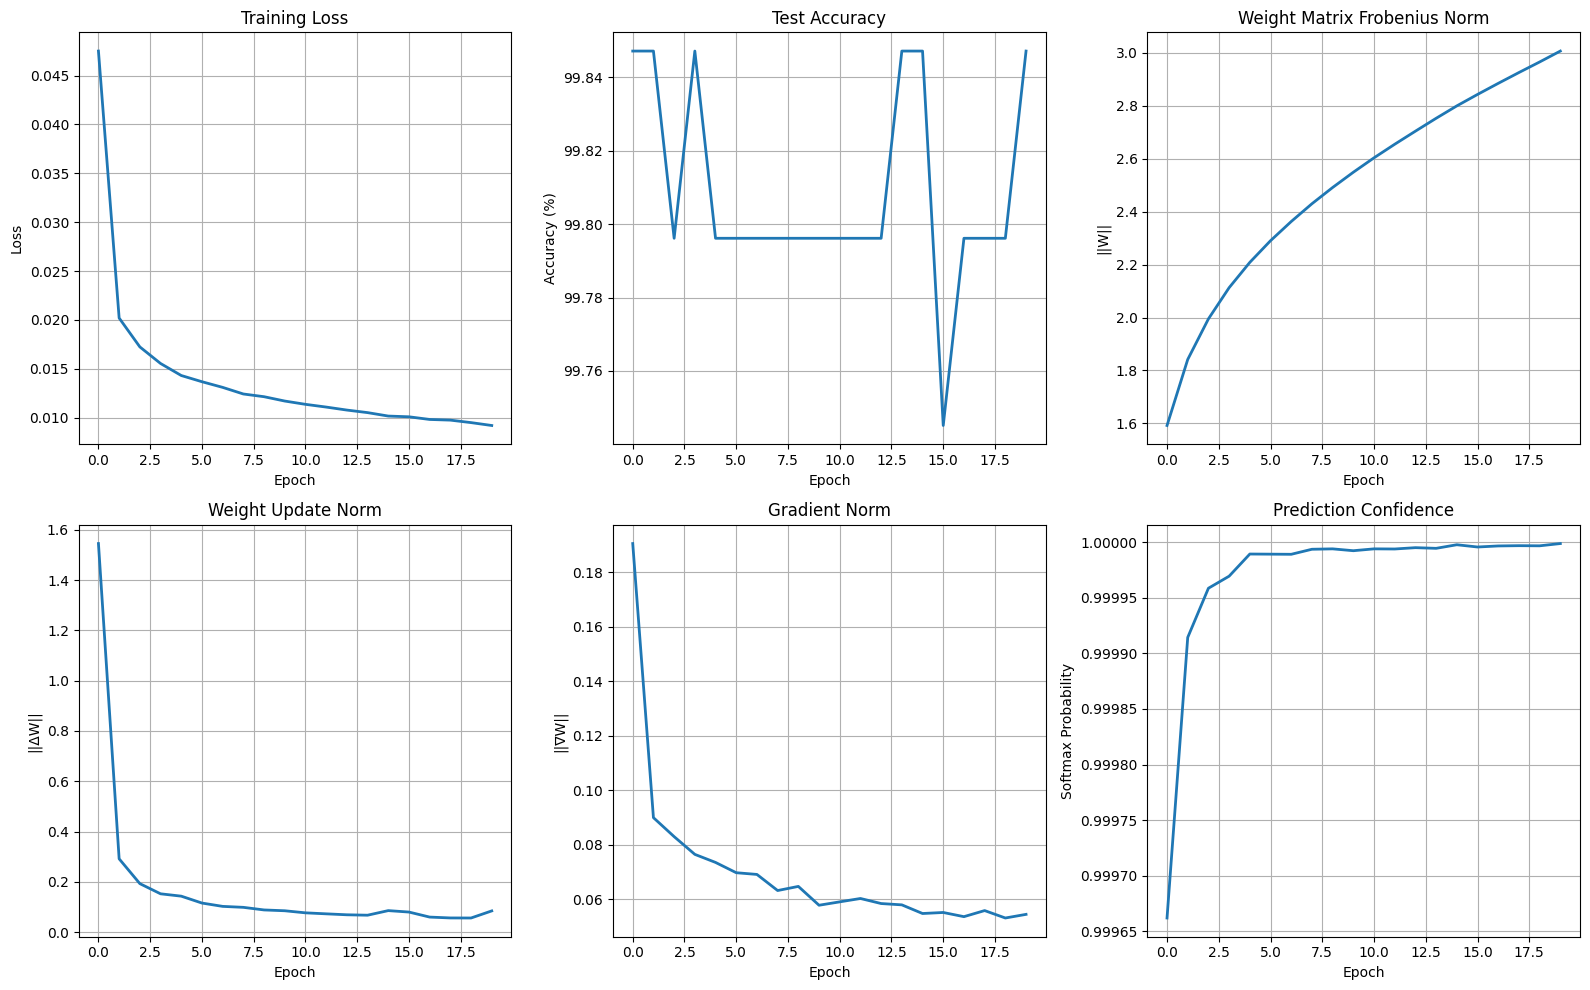

In [64]:
plt.figure(figsize=(16,10))

# -------------------------
# Loss
# -------------------------
plt.subplot(2,3,1)
plt.plot(loss_history, linewidth=2)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

# -------------------------
# Accuracy
# -------------------------
plt.subplot(2,3,2)
plt.plot(accuracy_history, linewidth=2)
plt.title("Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True)

# -------------------------
# Weight Norm
# -------------------------
plt.subplot(2,3,3)
plt.plot(weight_norm_history, linewidth=2)
plt.title("Weight Matrix Frobenius Norm")
plt.xlabel("Epoch")
plt.ylabel("||W||")
plt.grid(True)

# -------------------------
# Update Norm
# -------------------------
plt.subplot(2,3,4)
plt.plot(update_norm_history, linewidth=2)
plt.title("Weight Update Norm")
plt.xlabel("Epoch")
plt.ylabel("||ΔW||")
plt.grid(True)

# -------------------------
# Gradient Norm
# -------------------------
plt.subplot(2,3,5)
plt.plot(gradient_norm_history, linewidth=2)
plt.title("Gradient Norm")
plt.xlabel("Epoch")
plt.ylabel("||∇W||")
plt.grid(True)

# -------------------------
# Confidence
# -------------------------
plt.subplot(2,3,6)
plt.plot(confidence_history, linewidth=2)
plt.title("Prediction Confidence")
plt.xlabel("Epoch")
plt.ylabel("Softmax Probability")
plt.grid(True)

plt.tight_layout()
plt.show()

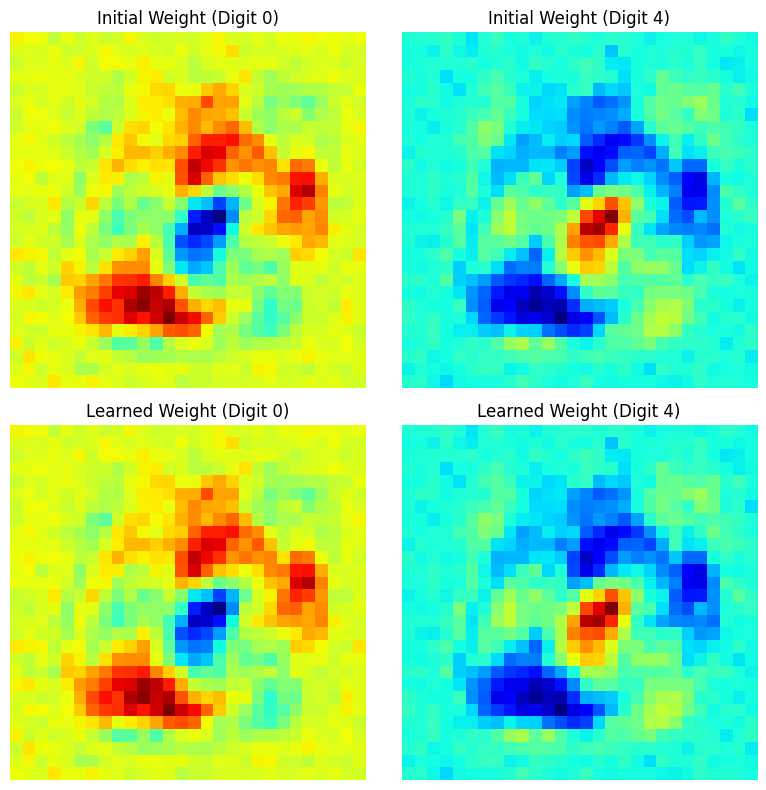

In [65]:
fig, ax = plt.subplots(2,2, figsize=(8,8))

ax[0,0].imshow(previous_W[0].reshape(28,28), cmap='jet')
ax[0,0].set_title("Initial Weight (Digit 0)")
ax[0,0].axis("off")

ax[0,1].imshow(previous_W[1].reshape(28,28), cmap='jet')
ax[0,1].set_title("Initial Weight (Digit 4)")
ax[0,1].axis("off")

ax[1,0].imshow(model.W[0].detach().reshape(28,28), cmap='jet')
ax[1,0].set_title("Learned Weight (Digit 0)")
ax[1,0].axis("off")

ax[1,1].imshow(model.W[1].detach().reshape(28,28), cmap='jet')
ax[1,1].set_title("Learned Weight (Digit 4)")
ax[1,1].axis("off")

plt.tight_layout()
plt.show()

In [66]:
after_accuracy = accuracy(model, X_test, y_test)

print()

print("Accuracy Before Training : {:.2f}%".format(before_accuracy))

print("Accuracy After Training  : {:.2f}%".format(after_accuracy))


Accuracy Before Training : 47.15%
Accuracy After Training  : 99.85%


Softmax Probabilities
Digit 0 : 0.9999986886978149
Digit 4 : 1.321525928688061e-06

Predicted Digit : 0
Actual Digit    : 0


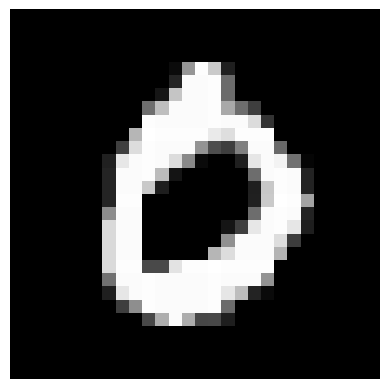

In [67]:
with torch.no_grad():

    probability = model(sample.unsqueeze(0))

prediction = torch.argmax(probability, dim=1).item()

print("Softmax Probabilities")

print("Digit 0 :", probability[0,0].item())
print("Digit 4 :", probability[0,1].item())

print()

print("Predicted Digit :", 0 if prediction==0 else 4)
print("Actual Digit    :", 0 if true_label==0 else 4)

plt.imshow(sample.reshape(28,28), cmap="gray")
plt.axis("off")
plt.show()

In [68]:
print("Weight Matrix Shape")

print(model.W.shape)

print()

print("Learned Weight Matrix")

print(model.W)

Weight Matrix Shape
torch.Size([2, 784])

Learned Weight Matrix
Parameter containing:
tensor([[ 1.9269e-02,  1.4873e-02,  9.0072e-03,  ...,  7.6927e-03,
         -7.6689e-03, -9.4949e-03],
        [ 1.6917e-04,  8.0277e-04,  7.4484e-03,  ...,  4.1337e-03,
          6.1524e-05, -5.6728e-03]], requires_grad=True)


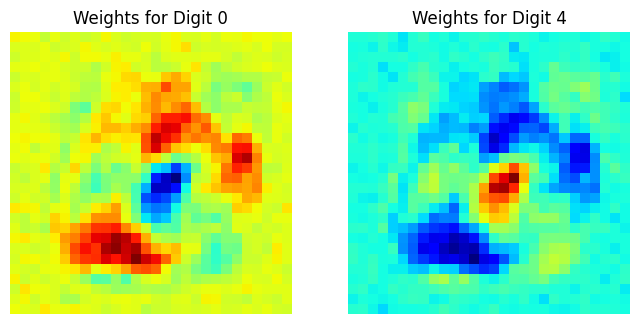

In [69]:
fig, ax = plt.subplots(1,2, figsize=(8,4))

ax[0].imshow(model.W[0].detach().numpy().reshape(28,28), cmap="jet")
ax[0].set_title("Weights for Digit 0")
ax[0].axis("off")

ax[1].imshow(model.W[1].detach().numpy().reshape(28,28), cmap="jet")
ax[1].set_title("Weights for Digit 4")
ax[1].axis("off")

plt.show()